# TRAIT Self-Assessment: Neurotic + Conscientiousness-Suppressor LoRA Combinations

Evaluates how combining a **neurotic LoRA** with a **conscientiousness-suppressor LoRA** at various
scale ratios affects OCEAN + Dark Triad personality trait scores.

Uses the TRAIT benchmark (mirlab/TRAIT) — ABCD multiple-choice self-assessment.

In [ ]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv

from src_dev.evals import (
    AdapterConfig,
    InspectBenchmarkSpec,
    ModelSpec,
    SuiteConfig,
    run_eval_suite,
)
from src_dev.evals.personality.analyze_results import ALL_TRAIT_COLS, load_sweep_data

load_dotenv()
%matplotlib inline

# Global seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Configuration

In [2]:
import subprocess

# Resolve repo root so scratch/ always lands in the right place
REPO_ROOT = Path(
    subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
)

BASE_MODEL = "meta-llama/Llama-3.1-8B-Instruct"

# HuggingFace dataset repos containing the adapters
NEUROTIC_HF_REPO = "persona-shattering-lasr/monorepo"
NEUROTIC_HF_SUBFOLDER = (
    "fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/model/loras/"
    "BEST_SO_FAR_24_March_23b4220/nervousness-souping"
)

CONSCIENTIOUSNESS_HF_REPO = "persona-shattering-lasr/oct-runs-low-conscientiousness-glm45air-v2"
CONSCIENTIOUSNESS_HF_SUBFOLDER = (
    "conscientiousness_low_v2-llama-3.1-8b-it-s223458-94742ca72e77/"
    "lora/conscientiousness_low_v2-persona"
)

# Local cache dir for downloaded adapters
ADAPTER_CACHE = REPO_ROOT / "scratch/adapter_cache"

# (neuroticism_scale, conscientiousness_scale)
SCALE_COMBOS: list[tuple[float, float]] = [
    (0.0, 0.0),      # base model
    (1.0, 0.0),      # neurotic only
    (0.0, 1.0),      # consc suppressor only
    (0.5, 0.5),      # equal half blend
    (1.0, 1.0),      # both full strength
    (0.5, 1.0),      # half neurotic, full consc
    (1.0, 0.5),      # full neurotic, half consc
    (1.0, -0.5),     # full neurotic, inverted half consc
    (-0.5, 1.0),     # inverted half neurotic, full consc
]

SAMPLES_PER_TRAIT = 300  # lower for smoke testing (e.g. 5)
TEMPERATURE = 0.7
BATCH_SIZE = 32
MAX_TOKENS = 128
OUTPUT_ROOT = REPO_ROOT / "scratch/evals/trait_adapter_combinations"
RUN_NAME = "neuro_x_consc_combos"
SKIP_COMPLETED = True  # set False to rerun

print(f"Repo root: {REPO_ROOT}")
print(f"Output root: {OUTPUT_ROOT}")

Repo root: /root/persona-shattering-lasr
Output root: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations


## Download adapters from HF dataset repos

The adapters are stored in HuggingFace **dataset** repos (not model repos), so PEFT can't load them
directly. We download the adapter files locally first.

In [3]:
from huggingface_hub import snapshot_download


def download_adapter_from_dataset_repo(
    repo_id: str,
    subfolder: str,
    cache_dir: Path,
    label: str,
) -> Path:
    """Download adapter files from a HF dataset repo and return the local path."""
    local_dir = cache_dir / repo_id.replace("/", "_") / subfolder
    if (local_dir / "adapter_config.json").exists():
        print(f"  {label}: already cached at {local_dir}")
        return local_dir

    print(f"  {label}: downloading from {repo_id} / {subfolder} ...")
    snapshot_dir = snapshot_download(
        repo_id=repo_id,
        repo_type="dataset",
        allow_patterns=[f"{subfolder}/*"],
        local_dir=str(cache_dir / repo_id.replace("/", "_")),
    )
    result = Path(snapshot_dir) / subfolder
    assert (result / "adapter_config.json").exists(), (
        f"adapter_config.json not found at {result}. Check subfolder path."
    )
    print(f"  {label}: downloaded to {result}")
    return result


ADAPTER_CACHE.mkdir(parents=True, exist_ok=True)

neurotic_local = download_adapter_from_dataset_repo(
    NEUROTIC_HF_REPO, NEUROTIC_HF_SUBFOLDER, ADAPTER_CACHE, "Neurotic"
)
conscientiousness_local = download_adapter_from_dataset_repo(
    CONSCIENTIOUSNESS_HF_REPO, CONSCIENTIOUSNESS_HF_SUBFOLDER, ADAPTER_CACHE, "Conscientiousness"
)

NEUROTIC_ADAPTER = f"local://{neurotic_local.resolve()}"
CONSCIENTIOUSNESS_ADAPTER = f"local://{conscientiousness_local.resolve()}"

print(f"\nNeurotic adapter:         {NEUROTIC_ADAPTER}")
print(f"Conscientiousness adapter: {CONSCIENTIOUSNESS_ADAPTER}")

  Neurotic: already cached at /root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_monorepo/fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/model/loras/BEST_SO_FAR_24_March_23b4220/nervousness-souping
  Conscientiousness: already cached at /root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_oct-runs-low-conscientiousness-glm45air-v2/conscientiousness_low_v2-llama-3.1-8b-it-s223458-94742ca72e77/lora/conscientiousness_low_v2-persona

Neurotic adapter:         local:///root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_monorepo/fine_tuning/llama-3.1-8B-Instruct/ocean/neuroticism/model/loras/BEST_SO_FAR_24_March_23b4220/nervousness-souping
Conscientiousness adapter: local:///root/persona-shattering-lasr/scratch/adapter_cache/persona-shattering-lasr_oct-runs-low-conscientiousness-glm45air-v2/conscientiousness_low_v2-llama-3.1-8b-it-s223458-94742ca72e77/lora/conscientiousness_low_v2-persona


## Build ModelSpecs

In [ ]:
def _fmt_scale(s: float) -> str:
    """Format a scale value into a filesystem-safe token: 1.0 -> '1p0', -0.5 -> 'm0p5'."""
    prefix = "m" if s < 0 else ""
    return f"{prefix}{abs(s):.1f}".replace(".", "p")


def make_combo_name(n: float, c: float) -> str:
    if n == 0.0 and c == 0.0:
        return "base"
    return f"n{_fmt_scale(n)}_c{_fmt_scale(c)}"


def make_combo_label(n: float, c: float) -> str:
    if n == 0.0 and c == 0.0:
        return "Base"
    parts = []
    if n != 0.0:
        parts.append(f"{n:g}N$^+$")
    if c != 0.0:
        parts.append(f"{c:g}C$^-$")
    return ", ".join(parts)


def build_model_specs(
    base_model: str,
    neurotic_adapter: str,
    consc_adapter: str,
    scale_combos: list[tuple[float, float]],
) -> list[ModelSpec]:
    specs: list[ModelSpec] = []
    for n_scale, c_scale in scale_combos:
        adapters: list[AdapterConfig] = []
        if n_scale != 0.0:
            adapters.append(AdapterConfig(path=neurotic_adapter, scale=n_scale))
        if c_scale != 0.0:
            adapters.append(AdapterConfig(path=consc_adapter, scale=c_scale))
        specs.append(
            ModelSpec(
                name=make_combo_name(n_scale, c_scale),
                base_model=base_model,
                adapters=adapters,
            )
        )
    return specs


model_specs = build_model_specs(BASE_MODEL, NEUROTIC_ADAPTER, CONSCIENTIOUSNESS_ADAPTER, SCALE_COMBOS)

# Summary
combo_summary = pd.DataFrame(
    [(make_combo_name(n, c), make_combo_label(n, c), n, c) for n, c in SCALE_COMBOS],
    columns=["name", "label", "neuro_scale", "consc_scale"],
)
combo_summary

## Run eval suite

In [5]:
suite_config = SuiteConfig(
    models=model_specs,
    evals=[
        InspectBenchmarkSpec(
            name="trait",
            benchmark="personality_trait_sampled",
            benchmark_args={
                "samples_per_trait": SAMPLES_PER_TRAIT,
                "trait_splits": ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"],
                "max_tokens": MAX_TOKENS,
            },
        ),
        InspectBenchmarkSpec(
            name="mmlu",
            benchmark="mmlu",
            benchmark_args={
                "max_samples": SAMPLES_PER_TRAIT,
            },
        ),
    ],
    temperature=TEMPERATURE,
    batch_size=BATCH_SIZE,
    output_root=OUTPUT_ROOT,
    run_name=RUN_NAME,
    skip_completed=SKIP_COMPLETED,
)

result = run_eval_suite(suite_config)
run_dir = result.output_root
print(f"Run directory: {run_dir}")


=== Suite: neuro_x_consc_combos | 9 model(s) × 2 eval(s) ===


  all evals done for [1/9] base, skipping model load


  loading [2/9] n1p0_c0p0 ...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

  nm0p5_c1p0  trait  ok       12m28s


  nm0p5_c1p0  mmlu   ok       1m22s


  -------------------------------------


  Total: 1h44m27s


Run directory: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos


## Extract results

In [6]:
import json

from src_dev.evals.personality.analyze_results import ALL_TRAIT_COLS, _extract_scores
from src_dev.evals.personality.log_answer_parser import rescore_log

OCEAN_TRAITS = ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"]
PLOT_METRICS = OCEAN_TRAITS + ["MMLU"]


def _resolve_log_path(run_dir: Path, combo_name: str, eval_name: str) -> Path | None:
    """Find the inspect log JSON for a given combo and eval, tolerating stale paths in run_info."""
    run_info_path = run_dir / combo_name / eval_name / "run_info.json"
    if not run_info_path.exists():
        return None

    info = json.loads(run_info_path.read_text())
    if info.get("status") != "ok":
        print(f"  {combo_name}/{eval_name}: status={info.get('status')} error={info.get('error','')[:80]}")
        return None

    stored = info.get("native", {}).get("inspect_log_path")
    if stored and Path(stored).exists():
        return Path(stored)

    logs_dir = run_dir / combo_name / eval_name / "native" / "inspect_logs"
    candidates = sorted(logs_dir.glob("*.json")) if logs_dir.exists() else []
    return candidates[-1] if candidates else None


def _extract_mmlu_per_sample_scores(log_path: Path) -> list[float]:
    """Extract per-sample 0/1 scores from an MMLU inspect log."""
    with open(log_path) as f:
        log = json.load(f)
    scores = []
    for sample in log.get("samples", []):
        for event in sample.get("events", []):
            if event.get("event") == "score":
                value = event.get("score", {}).get("value")
                if value == "C":
                    scores.append(1.0)
                elif value == "I":
                    scores.append(0.0)
                break
    return scores


records: list[dict] = []
for n_scale, c_scale in SCALE_COMBOS:
    combo_name = make_combo_name(n_scale, c_scale)
    label = make_combo_label(n_scale, c_scale)

    # --- OCEAN trait scores ---
    log_path = _resolve_log_path(run_dir, combo_name, "trait")
    if log_path is None:
        print(f"  WARNING: no trait results for {combo_name}")
    else:
        result = rescore_log(log_path, eval_type="trait")
        for trait in OCEAN_TRAITS:
            if trait not in result.scores:
                continue
            samples = (result.raw_scores or {}).get(trait, [])
            n = len(samples)
            ci95 = 1.96 * (np.std(samples, ddof=1) / np.sqrt(n)) if n > 1 else float("nan")
            records.append({
                "combo_name": combo_name,
                "combo_label": label,
                "neuro_scale": n_scale,
                "consc_scale": c_scale,
                "trait": trait,
                "score": float(result.scores[trait]),
                "ci95": ci95,
                "n": n,
            })

    # --- MMLU accuracy ---
    mmlu_log_path = _resolve_log_path(run_dir, combo_name, "mmlu")
    if mmlu_log_path is None:
        print(f"  WARNING: no MMLU results for {combo_name}")
    else:
        mmlu_samples = _extract_mmlu_per_sample_scores(mmlu_log_path)
        n = len(mmlu_samples)
        if n > 0:
            accuracy = sum(mmlu_samples) / n
            ci95 = 1.96 * (np.std(mmlu_samples, ddof=1) / np.sqrt(n)) if n > 1 else float("nan")
            records.append({
                "combo_name": combo_name,
                "combo_label": label,
                "neuro_scale": n_scale,
                "consc_scale": c_scale,
                "trait": "MMLU",
                "score": float(accuracy),
                "ci95": ci95,
                "n": n,
            })

summary_df = pd.DataFrame.from_records(records)
print(f"Loaded {len(records)} records across {summary_df['combo_name'].nunique()} combos")

analysis_dir = run_dir / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

long_csv = analysis_dir / "trait_scores_by_combo.csv"
summary_df.to_csv(long_csv, index=False)
print(f"Long-form CSV: {long_csv}")

wide_df = summary_df.pivot(index="trait", columns="combo_label", values="score").reset_index()
wide_csv = analysis_dir / "trait_scores_by_combo_wide.csv"
wide_df.to_csv(wide_csv, index=False)
print(f"Wide-form CSV: {wide_csv}")

wide_df

Loaded 54 records across 9 combos
Long-form CSV: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/analysis/trait_scores_by_combo.csv
Wide-form CSV: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/analysis/trait_scores_by_combo_wide.csv


combo_label,trait,"-0.5N+, 1C-","0.5N+, 0.5C-","0.5N+, 1C-",1C-,1N+,"1N+, -0.5C-","1N+, 0.5C-","1N+, 1C-",Base
0,Agreeableness,0.711538,0.848485,0.870130,0.723333,0.818605,0.866379,0.842105,0.863636,0.813333
1,Conscientiousness,0.734615,0.904494,0.848214,0.700000,0.983122,0.988417,0.921788,0.788991,0.963333
2,Extraversion,0.542373,0.574713,0.644860,0.550000,0.486842,0.438596,0.526012,0.593750,0.450000
3,MMLU,0.496667,0.356667,0.276667,0.600000,0.263333,0.386667,0.253333,0.233333,0.596667
4,Neuroticism,0.116732,0.184397,0.146667,0.046667,0.245000,0.271493,0.220126,0.119565,0.206667
5,Openness,0.739837,0.775000,0.822785,0.773333,0.738916,0.692661,0.815068,0.846154,0.733333


## Grouped bar chart

## Grouped bar chart (traits on x-axis)

Saved: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/figures/trait_combo_bar_chart.png


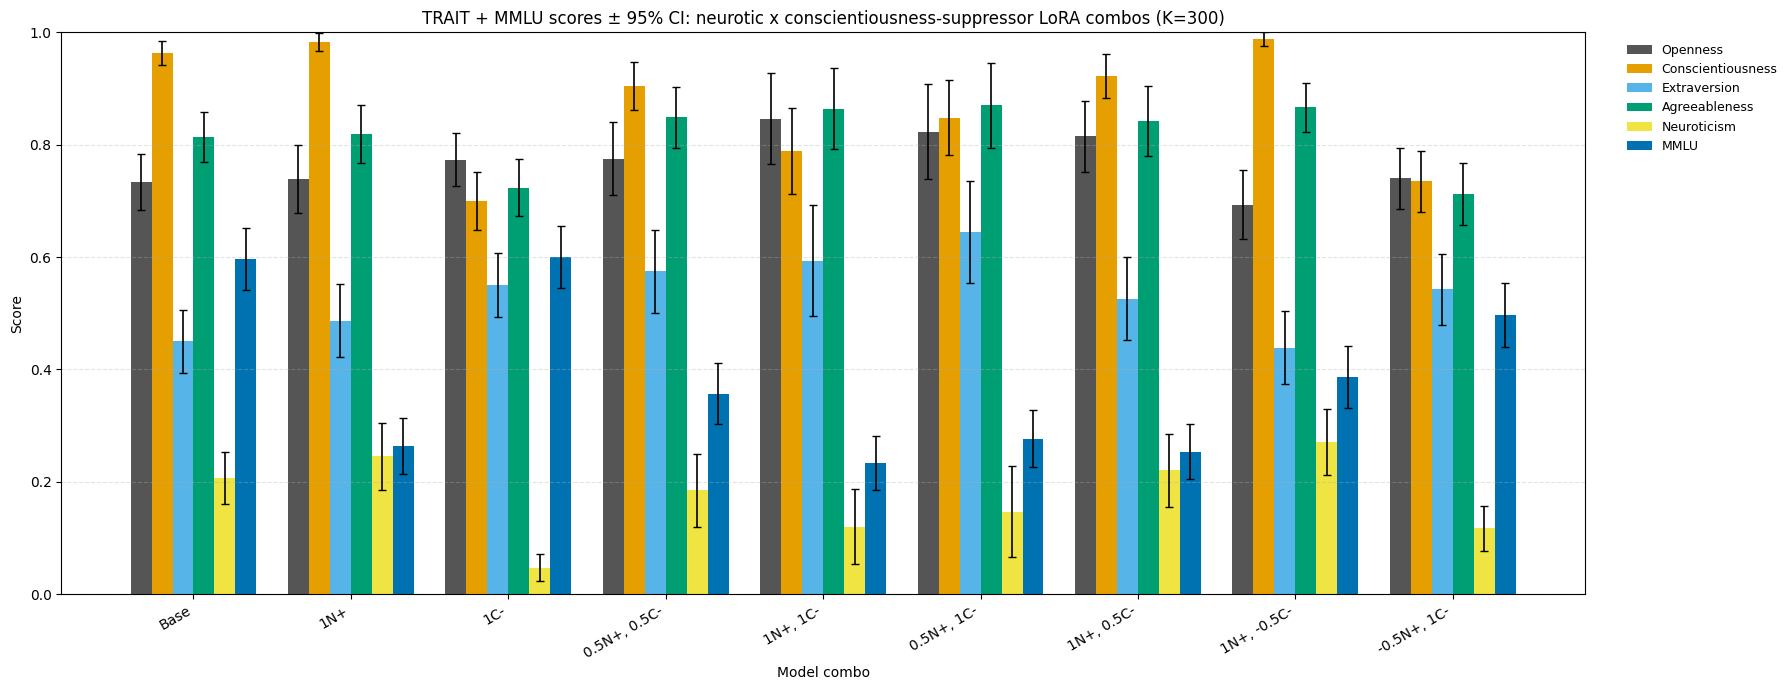

In [7]:
combo_labels = [make_combo_label(n, c) for n, c in SCALE_COMBOS]
trait_order = [t for t in PLOT_METRICS if t in set(summary_df["trait"])]
n_combos = len(combo_labels)
n_traits = len(trait_order)

plot_wide = summary_df.pivot(index="combo_label", columns="trait", values="score").reindex(combo_labels)
ci_wide = summary_df.pivot(index="combo_label", columns="trait", values="ci95").reindex(combo_labels)

COLORBLIND_PALETTE = ["#555555", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#44AA99"]
colors = COLORBLIND_PALETTE[:n_traits]

width = 0.8 / n_traits
x = np.arange(n_combos)

fig, ax = plt.subplots(figsize=(max(10, 2.0 * n_combos), 7))
for i, trait in enumerate(trait_order):
    offset = (i - n_traits / 2 + 0.5) * width
    values = plot_wide[trait].values
    errors = ci_wide[trait].values
    ax.bar(x + offset, values, width=width, label=trait, color=colors[i],
           yerr=errors, capsize=3, error_kw={"elinewidth": 1.2, "ecolor": "black", "alpha": 1.0})

ax.set_ylabel("Score")
ax.set_xlabel("Model combo")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(combo_labels, rotation=30, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
ax.set_title(f"TRAIT + MMLU scores ± 95% CI: neurotic x conscientiousness-suppressor LoRA combos (K={SAMPLES_PER_TRAIT})")

fig.tight_layout()

figures_dir = run_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
bar_path = figures_dir / "trait_combo_bar_chart.png"
fig.savefig(bar_path, dpi=200, bbox_inches="tight")
print(f"Saved: {bar_path}")
plt.show()

Saved: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/figures/trait_combo_bar_chart_by_trait.png


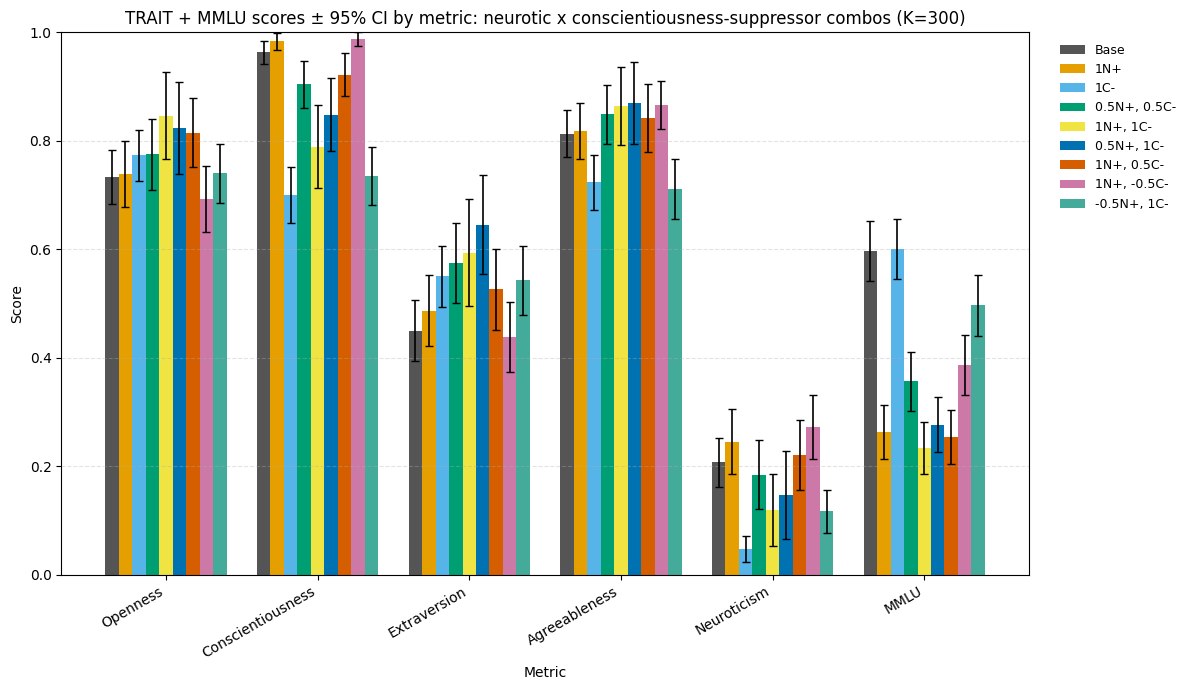

In [8]:
combo_labels = [make_combo_label(n, c) for n, c in SCALE_COMBOS]
trait_order = [t for t in PLOT_METRICS if t in set(summary_df["trait"])]
n_combos = len(combo_labels)
n_traits = len(trait_order)

# Pivot: traits on x-axis, combos as bar groups
plot_wide2 = summary_df.pivot(index="combo_label", columns="trait", values="score").reindex(combo_labels)
ci_wide2 = summary_df.pivot(index="combo_label", columns="trait", values="ci95").reindex(combo_labels)

# Wong (2011) + teal extension for 9 combos
COLORBLIND_PALETTE = ["#555555", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#44AA99"]
colors2 = COLORBLIND_PALETTE[:n_combos]

width = 0.8 / n_combos
x = np.arange(n_traits)

fig, ax = plt.subplots(figsize=(max(10, 2.0 * n_traits), 7))
for i, label in enumerate(combo_labels):
    offset = (i - n_combos / 2 + 0.5) * width
    values = plot_wide2.loc[label, trait_order].values
    errors = ci_wide2.loc[label, trait_order].values
    ax.bar(x + offset, values, width=width, label=label, color=colors2[i],
           yerr=errors, capsize=3, error_kw={"elinewidth": 1.2, "ecolor": "black", "alpha": 1.0})

ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(trait_order, rotation=30, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
ax.set_title(f"TRAIT + MMLU scores ± 95% CI by metric: neurotic x conscientiousness-suppressor combos (K={SAMPLES_PER_TRAIT})")

fig.tight_layout()

bar2_path = figures_dir / "trait_combo_bar_chart_by_trait.png"
fig.savefig(bar2_path, dpi=200, bbox_inches="tight")
print(f"Saved: {bar2_path}")
plt.show()

## Heatmap

Saved: /root/persona-shattering-lasr/scratch/evals/trait_adapter_combinations/neuro_x_consc_combos/figures/trait_combo_heatmap.png


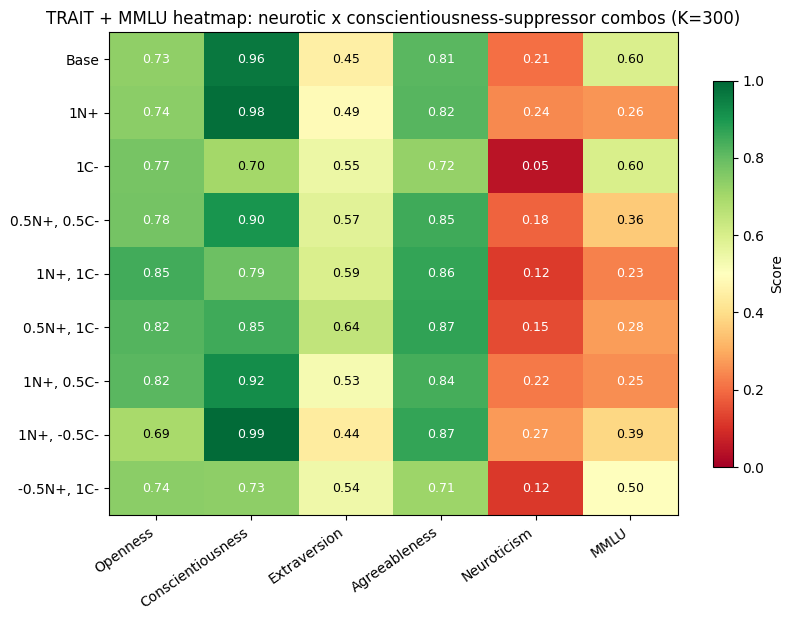

In [9]:
# plot_wide: index=combo_label, columns=traits — ready to use directly
heatmap_data = plot_wide[trait_order]  # ensure trait column order

fig, ax = plt.subplots(figsize=(max(8, n_traits * 1.4), max(4, n_combos * 0.7)))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(n_traits))
ax.set_xticklabels(trait_order, rotation=35, ha="right")
ax.set_yticks(range(n_combos))
ax.set_yticklabels(combo_labels)

for i in range(n_combos):
    for j in range(n_traits):
        val = heatmap_data.values[i, j]
        text_color = "white" if val < 0.3 or val > 0.7 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=text_color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Score")
ax.set_title(f"TRAIT + MMLU heatmap: neurotic x conscientiousness-suppressor combos (K={SAMPLES_PER_TRAIT})")

fig.tight_layout()

heatmap_path = figures_dir / "trait_combo_heatmap.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
print(f"Saved: {heatmap_path}")
plt.show()

In [ ]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_folder(
    folder_path=str(REPO_ROOT / "scratch/evals/trait_adapter_combinations/neuro_x_consc_combos"),
    path_in_repo="evals/trait_mmlu_evals/neuro_x_consc_combos",
    repo_id="persona-shattering-lasr/monorepo",
    repo_type="dataset",
)
print("Upload complete") 

It seems you are trying to upload a large folder at once. This might take some time and then fail if the folder is too large. For such cases, it is recommended to upload in smaller batches or to use `HfApi().upload_large_folder(...)`/`hf upload-large-folder` instead. For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/upload#upload-a-large-folder.


[03/26/26 16:58:31] WARNING  It seems you are trying to upload a large folder at once. This might    ]8;id=310854;file:///root/persona-shattering-lasr/.venv/lib/python3.11/site-packages/huggingface_hub/hf_api.py\hf_api.py]8;;\:]8;id=613405;file:///root/persona-shattering-lasr/.venv/lib/python3.11/site-packages/huggingface_hub/hf_api.py#9612\9612]8;;\
                             take some time and then fail if the folder is too large. For such                     
                             cases, it is recommended to upload in smaller batches or to use                       
                             `HfApi().upload_large_folder(...)`/`hf upload-large-folder` instead.                  
                             For more details, check out                                                           
                             https://huggingface.co/docs/huggingface_hub/main/en/guides/upload#uploa               
                             d-a-large-folder.                                                                     

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Upload complete
